## Summary

This project trains a linear regression model to predict median house prices in California using 8 features including median income, house age, rooms, population, location, across 20,640 districts.

The results achieved by model: R²=0.576, MAE=0.533(approx.53,300), RMSE=(approx.74,600).

Median income emerged to be the strongest predictor of price, consistent with real world intuition.

In [1]:
# Import pandas for data handling and the California housing dataset from scikit-learn
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load the dataset as a pandas DataFrame
data = fetch_california_housing(as_frame=True)

# Combine the features (data.data) with the target column (house price), renaming it clearly
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

# Check the shape (rows, columns) and preview the first 5 rows
print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# Check if any column has missing values 
print(df.isnull().sum())

# See which features correlate most strongly with house price
# Higher absolute value = stronger relationship (positive or negative)
print("\n--Correlation with MedHouseVal--")
print(df.corr()['MedHouseVal'].sort_values(ascending=False))

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

--Correlation with MedHouseVal--
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


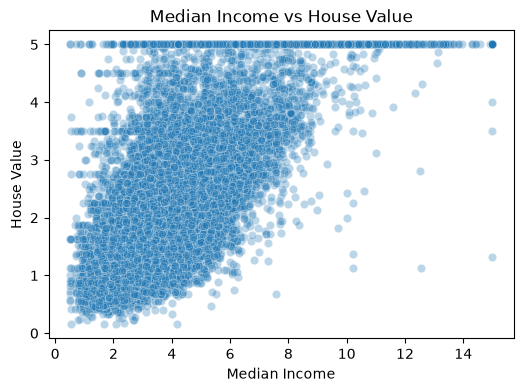

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the relationship between median income and house price
# since income showed the strongest correlation above
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['MedInc'], y=df['MedHouseVal'], alpha=0.3)
plt.title('Median Income vs House Value')
plt.xlabel('Median Income')
plt.ylabel('House Value')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Separate features (X) from the target we want to predict (y)
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Split into 80% training and 20% testing data
# random_state=42 ensures the split is reproducible every time we run this
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Linear Regression model on the training data only
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Number of training rows:", len(X_train))
print("Number of testing rows:", len(X_test))

Model trained successfully!
Number of training rows: 16512
Number of testing rows: 4128


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Use the trained model to predict prices on the test set 
y_pred = model.predict(X_test)

# Calculate three key evaluation metrics:
mae = mean_absolute_error(y_test, y_pred)          # Average absolute error
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Penalizes large errors more
r2 = r2_score(y_test, y_pred)                      # % of variance explained by the model

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")

MAE: 0.533
RMSE: 0.746
R2: 0.576


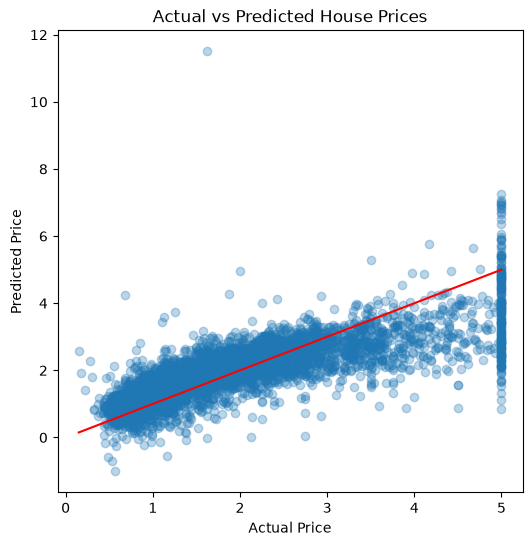

In [6]:
# Visualize how close our predictions are to actual values
# Points closer to the red diagonal line = more accurate predictions
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.show()

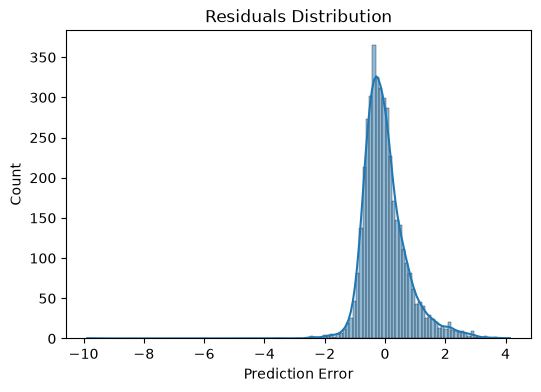

In [7]:
# Residuals = actual price minus predicted price
# A distribution centered around 0 means the model isn't systematically over/under-predicting
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Prediction Error")
plt.show()

## Limitation & Improvements Ideas

1. I noticed all houses prices stop exactly at $500,000. This dataset does not record any higher prices than that, so the model can't predict beyond that either, which shows a clear straight line of dots in my plot.
2. There was this one prediction which was by far outside the realistic range, which implies the model is sensitive to unusual feature combination.
3. Linear Regression assumes straight lines relationships between features and price. A different model could improve R² by analyzing and capturing more complex patterns.